# Validation of scenario reproduction

The ATAG Waypoint reports are dense and information-heavy, meaning many assumptions are explicit and quantified in the report itself. However, for scenario reproduction purposes with AeroMAPS, we may either try to approximate results by tweaking parameters, or directly feed on report data.

Relative to the 2nd Edition of the ATAG Waypoint report, the 3rd edition has fewer available data in the main report (meaning many missing inputs were filled with information from the 2nd edition). The traffic growth assumptions remained similar to the 2nd edition, as their central scenario had close agreement to observed traffic evolution. The technology scenarios were revised, where a T0 was included (the baseline is now seen as the 2019-rozen fuel efficiency), and the T5 was removed (delays on hydrogen aircraft development). Operational improvements are similar to the 2nd edition. SAF deployment was revised to reflect production delays, BUT their scale-up is now more intense to compensate for delays. Carbon offsets (MBMs) were also modified between editions, where the 2nd ed. considered MBMs to cap emissions at 2019 level until 2035 then reduce linearly until 2050, while the 3rd ed. does not cap the 2019 until 2035, and the emissions path from 2035-2050 is not linear anymore.

Here is a summarization made by gen-AI after reading both reports:
"The transition from ATAG’s Waypoint 2050 2nd to 3rd edition reflects a shift from a policy-imposed pathway (cap at 2019 levels via offsets, then linear decline) to a feasibility-driven trajectory based on real deployment constraints. The pre-2035 cap was dropped because the underlying assumptions—stable post-2019 growth and large-scale credible offsets—proved unrealistic, while mitigation now depends mainly on slower, uncertain scaling of SAF and new technologies, producing a non-linear reduction curve. In parallel, International Civil Aviation Organization’s LTAG (2022) formalized this shift by adopting a non-binding net-zero 2050 goal without intermediate caps or enforcement, meaning no binding decision replaced the earlier cap logic; accountability is therefore indirect, increasingly driven by regional policies (e.g. EU ETS) and financial pressures rather than global regulation."

In [1]:
%matplotlib widget

import gemseo as gm
import numpy as np
import matplotlib.pyplot as plt

from aeromaps import create_process, create_multi_process
from aeromaps.utils.functions import custom_logger_config

from scipy.interpolate import interp1d

custom_logger_config(gm.configure_logger())

central_years = [2018.8997457648195,2019.267285427373,2019.4397114419044,2019.6121374564357,2019.7845634709668,2020.2450193052266,2021.0130988245023,2021.5088236162796,2021.9075587748832,2022.3278471853032,2022.7804654734477,2023.4486162797566,2024.310746352413,2025.317871028198,2026.2246751137102,2027.1514649418157,2027.9943930264901,2028.8800357374919,2029.727796975604,2030.575558213716,2031.4879792072772,2032.4696318581884,2033.4062186189378,2034.35456169886,2035.3029047787818,2036.2394915395314,2037.2211441904424,2038.1694872703642,2039.1178303502863,2040.0759703628523,2040.9714100064975,2041.9295500190635,2042.824989662709,2043.7204293063542,2044.6883662515638,2045.6131966931407,2046.51843326943,2047.4804920550534,2048.3680941525836,2049.4512089493974,2050.41695463406]
central_rpk = [8.298478276716722,7.069210959141273,6.099989179362879,5.121395895482632,4.159225056885635,3.1963438050868724,3.7054143657588945,4.791509695290856,5.690298312106368,6.668800646550885,7.6350415512465375,8.468811213889985,8.992313019390583,9.51540071770335,10.045642313019389,10.513467797783932,10.93699162679426,11.37475761772853,11.762205678670359,12.15446675900277,12.581862880886426,12.994557416267945,13.385396468144044,13.807738919667589,14.231886253462605,14.630765235457066,15.037946675900276,15.499274584487535,15.915119459833795,16.375265990934274,16.850770429362882,17.343995530093174,17.825406855955677,18.296973369428358,18.802996726265427,19.366119994963483,19.909553638881896,20.502047264542938,21.06336565096953,21.75173205467903,22.28689404432134]


atag_scenario_emissions = {
    "T0": (
        [2023.9677354180449,2025.3545812708353,2026.8180287571136,2028.3090884601138,2029.786342054753,2031.263595649392,2032.7546553523925,2034.2457150553928,2035.736774758393,2037.2278344613933,2038.7188941643938,2040.209953867394,2041.673401353672,2043.1506549483113,2044.6104692481786,2046.0739167344566,2047.545599443266,2049.0504652546274,2050.108933562313],
        [956.5765294738949,1039.7642550995474,1126.9888026500373,1208.4399901658785,1285.6083793060882,1359.795645128266,1429.3880390594256,1501.0089108405966,1573.6440215467733,1646.2011138741036,1718.8362245802803,1799.1171364134225,1887.0438493735319,1972.78194149547,2061.1808709591232,2153.9837325971444,2254.042303467898,2365.6119288633313,2415.9413064902556],
    ),
    "T1": (
        [2023.5402492396145,2025.0150307314618,2026.4875114721522,2027.9783982221009,2029.4865406057297,2030.9877807358864,2032.4959231195153,2033.979907615992,2035.509598498265,2037.0238013971375,2038.5112370203503,2040.029732784187,2041.5344240410798,2043.0241359393738,2044.4562801065822,2045.8524738131537,2047.264736684747,2048.640475628738,2049.9307653081023],
        [912.0283214801764,986.4137449153072,1054.484098373788,1117.3362439584503,1179.358928142274,1230.1897246922479,1277.393087932922,1318.1710459558335,1361.0400388430705,1398.8612846804988,1447.9552587141416,1506.679780348638,1562.0571239049245,1615.712046940896,1675.1764087997378,1734.7149210964167,1803.0055761382519,1874.9946376212201,1946.4663844583429],
    ),
    "T2": (
        [2023.5402492396145,2025.0150307314618,2026.4875114721522,2027.9783982221009,2029.4865406057297,2030.9877807358864,2032.4959231195153,2033.979907615992,2035.509598498265,2037.0238013971375,2038.5112370203503,2040.029732784187,2041.5344240410798,2043.0241359393738,2044.4562801065822,2045.8524738131537,2047.264736684747,2048.640475628738,2049.9307653081023],
        [912.0283214801764,986.4137449153072,1054.484098373788,1117.3362439584503,1179.358928142274,1230.1897246922479,1277.393087932922,1318.1710459558335,1361.0400388430705,1398.8612846804988,1433.0912937217518,1469.5198678676634,1510.03324643156,1546.34687697641,1585.9926188453987,1630.6671661496878,1679.1392012016697,1728.8323151960533,1795.3494070357126],
    ),
    "T3": (
        [2023.5402492396145,2025.0150307314618,2026.4875114721522,2027.9783982221009,2029.4865406057297,2030.9877807358864,2032.4959231195153,2033.979907615992,2035.509598498265,2037.0238013971375,2038.5112370203503,2040.029732784187,2041.5344240410798,2043.0241359393738,2044.4562801065822,2045.8524738131537,2047.264736684747,2048.640475628738,2049.9307653081023],
        [912.0283214801764,986.4137449153072,1054.484098373788,1117.3362439584503,1179.358928142274,1230.1897246922479,1277.393087932922,1318.1710459558335,1361.0400388430705,1398.8612846804988,1428.1366387242883,1459.6105578727368,1490.2146264417067,1519.0962744903618,1551.3100338631557,1583.5979436737864,1619.6833412321103,1659.4671452315672,1703.6882895826418],
    ),
    "T4": (
        [2023.5402492396145,2025.0150307314618,2026.4875114721522,2027.9783982221009,2029.4865406057297,2030.9877807358864,2032.4959231195153,2033.979907615992,2035.509598498265,2037.0238013971375,2038.5112370203503,2040.029732784187,2041.5344240410798,2043.0241359393738,2044.4562801065822,2045.8524738131537,2047.264736684747,2048.640475628738,2049.9307653081023],
        [912.0283214801764,986.4137449153072,1054.484098373788,1117.3362439584503,1179.358928142274,1230.1897246922479,1277.393087932922,1318.1710459558335,1361.0400388430705,1388.9519746855724,1415.7500012306302,1434.8372828854203,1450.5773864620005,1459.6404145208023,1474.5128814024747,1479.5501887270573,1493.3396387967964,1500.918185312742,1515.4113996790368],
    ),
}

## Traffic forecasts

As Air Traffic forecast is said not to have changed from edition 2 to edition 3, lets verify that with the central scenario.

We use the Compound Annual Growth Rates (CAGR) relative to Revenue Passenger Kilometers (RPK) shown using data extraction from images in the 2nd edition report, and compare them with the RPK from images in the 3rd edition.

    INFO - 14:19:02: Loaded custom model 'atag_offset' from 'C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\notebooks\scenarios\02_atag_w2050_3rd\models\atag_offset.py'


Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa

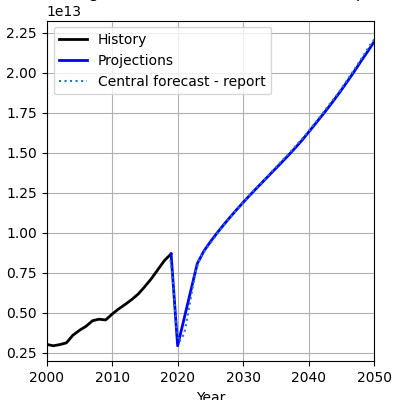

In [2]:
s1 = create_process(configuration_file="config_files/config_s1.yaml")
s1.compute()

plot_rpk = s1.plot("revenue_passenger_kilometer")
plot_rpk.ax.plot(central_years, np.array(central_rpk)*1e12, ":", label="Central forecast - report")
plot_rpk.ax.legend()

## Technology

Aircraft technology has significant improved since the commercialization of air travel, and efficiency gains have had a significant impact in reducing associated emissions.

Looking ahead, aircraft technology may continue with ever-modest efficiency gains, or adhere to disruptive technologies. We extract the CO2 emissions trajectory of 5 technological scenarios and fit annual efficiency gains based on these curbs.

    INFO - 14:19:07: Computing scenario: T0


Running MDA


    INFO - 14:19:09: Computing scenario: T1


Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
    INFO - 14:19

...

C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
    INFO - 14:19

Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
    INFO - 14:19

Running MDA


C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(
C:\Users\i.costa-alves\Documents\Kodigus\aeromaps\AeroMAPS\aeromaps\models\base.py:211: UserWarning: 
[Interpolation Model: passenger_aircraft_efficiency_simple_shares Warning]
The first reference year (2019) differs from the prospection start year (2020).
Interpolation will begin at the first reference year.
  warnings.warn(


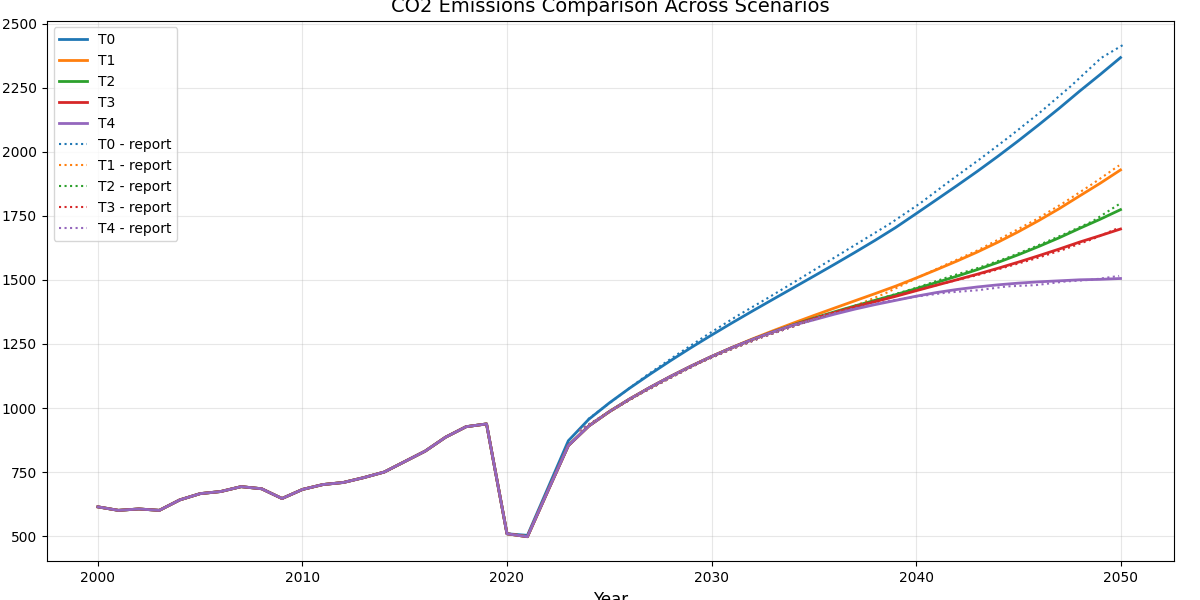

In [3]:
tech_variants = create_multi_process({
    f"T{i}": create_process(configuration_file=f"config_files/config_t{i}-TTW.yaml")
    for i in range(5)
})
tech_variants.compute_all()

plot_co2 = tech_variants.plot("co2_emissions_comparison")
for i, process in enumerate(tech_variants):
    scenario_name = tech_variants.get_scenario_names()[i]
    plot_co2.ax.plot(
        atag_scenario_emissions[scenario_name][0],
        atag_scenario_emissions[scenario_name][1],
        ":", label=f"{scenario_name} - report"
    )
plot_co2.ax.legend()


Compared to the 2nd edition, in the 3rd ed. all scenarios were revised with an additional 0.2% annual reduction in fuel burn in the 2019-2035 period, and in the T3 scenario (new configurations) after 2045 fuel burn annual reduction is lower (meaning aircraft will be less efficient) by 0.4%.

In [4]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals(), force_cleanup=False)

    INFO - 14:19:18: 🧹 clean_notebooks_on_tests called
    INFO - 14:19:18: ⏭ Skipping cleanup during notebook run
